In [1]:
import dynamiqs as dq
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from quantumQRC.reservoir_computing import Reservoir

from time import time

import jax.numpy as jnp


from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import QuantumParameters, JPCConfig



/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/qutip/settings.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Document

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bradaizakaria/Documents/Xenv/.venv/coeur/lib/python3.11/site-packages/ipykernel/ker

AttributeError: _ARRAY_API not found

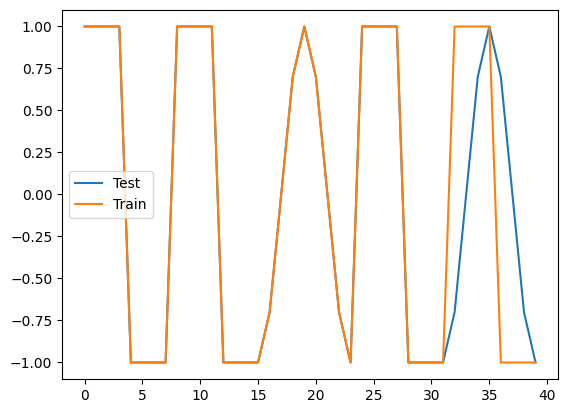

In [ ]:
def create_data(nb_periods_train: int, nb_periods_test: int):
    NB_POINTS_PER_PERIOD = 8
    sinus = np.array([-0.7, 0, 0.7, 1, 0.7, 0, -0.7, -1])
    square = np.array([1, 1, 1, 1, -1, -1, -1, -1])

    X_train_base = np.empty((nb_periods_train, NB_POINTS_PER_PERIOD))
    Y_train_base = 2 * np.random.binomial(1, 0.5, nb_periods_train) - 1

    for i in range(nb_periods_train):
        X_train_base[i, :] = sinus if Y_train_base[i] == 1 else square

    X_train = X_train_base.reshape(-1, 1)
    Y_train = np.repeat(Y_train_base, NB_POINTS_PER_PERIOD).reshape(-1, 1)


    X_test_base = np.empty((nb_periods_test, NB_POINTS_PER_PERIOD))
    Y_test_base = 2 * np.random.binomial(1, 0.5, (nb_periods_test, 1)) - 1

    for i in range(nb_periods_test):
        X_test_base[i, :] = sinus if Y_test_base[i] == 1 else square

    X_test = X_test_base.reshape(-1, 1)
    Y_test = np.repeat(Y_test_base, NB_POINTS_PER_PERIOD).reshape(-1, 1)

    return X_test, Y_test, X_train, Y_train

X_test, Y_test, X_train, Y_train = create_data(5, 5)
plt.plot(X_test, label='Test')
plt.plot(X_train, label='Train')
plt.legend()

In [3]:

params_G = [QuantumParameters(
    g_conv=700,
    g_sq=20,
    epsilon_a=50,
    epsilon_b=50,
    delta_a=0,
    delta_b=0
)]

QP_Dudas = JPCConfig(
    DIM_A=15,
    DIM_B=15,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)

QP = QP_Dudas

chip = JpcChip(QP_Dudas)



In [4]:
w = []
QRC = Reservoir(w, chip=chip)

In [6]:
a = QRC.train(X_train, Y_train, params_G, QP, encoding_observable='epsilon')

|██████████| 100.0% ◆ elapsed 02m02s ◆ remaining 0.00ms  


In [7]:
Y = QRC.test(X_test, Y_test, params_G, QP_Dudas, encoding_observable='epsilon')

|██████████| 100.0% ◆ elapsed 02m04s ◆ remaining 0.00ms  


In [8]:
treshold = 0
Y_corr = 2 * (Y[0] >= treshold) - 1
print(type(Y_corr))
acc = jnp.sum(Y_corr == Y_test) / len(Y_test)
print('Accuracy = ', acc *1e2, '%')


<class 'jaxlib._jax.ArrayImpl'>
Accuracy =  87.5 %


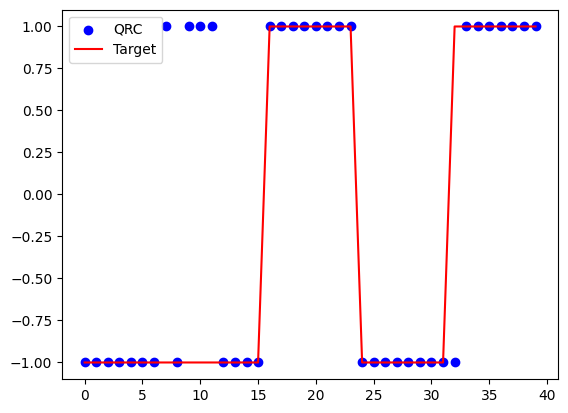

In [9]:
plt.scatter(range(len(Y_corr)), Y_corr, label='QRC', color='b')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.show()

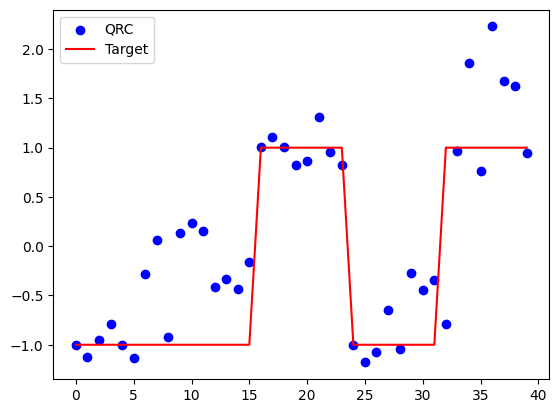

In [10]:
plt.scatter(range(len(Y[0])), Y[0], label='QRC', color='b')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.show()

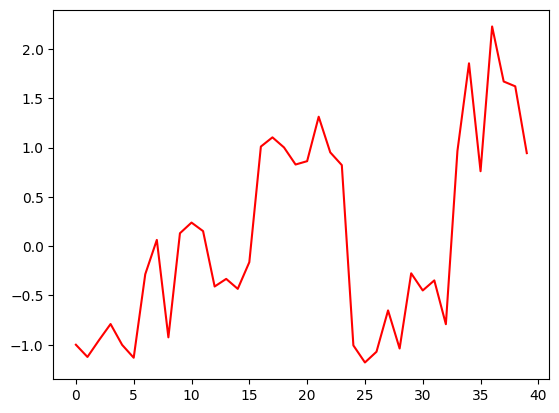

In [11]:
plt.plot(range(len(Y[0])), Y[0], label='Target', color='r')
